In [11]:
#depencies
import os, copy, time, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# Torch modules
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cpu


In [12]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## CNN Test Model

In [13]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x, return_activations=False):
        acts = {}

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        acts["conv1"] = x.detach()

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        acts["conv2"] = x.detach()

        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        acts["conv3"] = x.detach()

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        acts["fc1"] = x.detach()

        logits = self.fc2(x)

        if return_activations:
            return logits, acts

        return logits

## Train & test Utlities

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    torch.save(model.state_dict(), "temp_model.pth")
    size_mb = os.path.getsize("temp_model.pth") / (1024 * 1024)
    os.remove("temp_model.pth")
    return size_mb


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    avg_loss = total_loss / len(loader.dataset)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1": f1
    }


def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    best_model = copy.deepcopy(model.state_dict())
    best_f1 = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)

        val_metrics = evaluate(model, val_loader)

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_model = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss / len(train_loader.dataset):.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

    model.load_state_dict(best_model)
    return model

## Train Baseline

In [15]:
baseline_model = SmallCNN()

print("Baseline parameters:", count_parameters(baseline_model))
print("Baseline size before training:", model_size_mb(baseline_model), "MB")

baseline_model = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=8,
    lr=1e-3,
    weight_decay=1e-4
)

baseline_test = evaluate(baseline_model, test_loader)

print("\nBaseline Test Results")
print(baseline_test)
print("Parameters:", count_parameters(baseline_model))
print("Size MB:", model_size_mb(baseline_model))

Baseline parameters: 390858
Baseline size before training: 1.5004777908325195 MB
Epoch 01 | Train Loss: 0.3964 | Val Acc: 0.8840 | Val F1: 0.8819
Epoch 02 | Train Loss: 0.2564 | Val Acc: 0.8897 | Val F1: 0.8907
Epoch 03 | Train Loss: 0.2131 | Val Acc: 0.9128 | Val F1: 0.9144
Epoch 04 | Train Loss: 0.1837 | Val Acc: 0.9137 | Val F1: 0.9154
Epoch 05 | Train Loss: 0.1560 | Val Acc: 0.9180 | Val F1: 0.9185
Epoch 06 | Train Loss: 0.1361 | Val Acc: 0.9177 | Val F1: 0.9158
Epoch 07 | Train Loss: 0.1167 | Val Acc: 0.9212 | Val F1: 0.9216
Epoch 08 | Train Loss: 0.1002 | Val Acc: 0.9212 | Val F1: 0.9211

Baseline Test Results
{'loss': 0.24263223571777343, 'accuracy': 0.9191, 'f1': 0.9189300983940454}
Parameters: 390858
Size MB: 1.5004777908325195


## Dataset PCA

In [16]:
def dataset_pca_profile(loader, max_samples=5000, variance_threshold=0.95):
    xs = []

    for x, y in loader:
        x = x.view(x.size(0), -1)
        xs.append(x)

        if sum(t.size(0) for t in xs) >= max_samples:
            break

    X = torch.cat(xs, dim=0)[:max_samples].numpy()

    pca = PCA()
    pca.fit(X)

    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    num_components = np.searchsorted(cumulative_variance, variance_threshold) + 1

    profile = {
        "input_dim": X.shape[1],
        "samples_used": X.shape[0],
        "variance_threshold": variance_threshold,
        "num_components_needed": num_components,
        "compression_ratio_estimate": X.shape[1] / num_components,
        "cumulative_variance": cumulative_variance
    }

    return profile


dataset_profile = dataset_pca_profile(
    train_loader,
    max_samples=5000,
    variance_threshold=0.95
)

print("Dataset PCA Profile")
for k, v in dataset_profile.items():
    if k != "cumulative_variance":
        print(k, ":", v)

Dataset PCA Profile
input_dim : 784
samples_used : 5000
variance_threshold : 0.95
num_components_needed : 179
compression_ratio_estimate : 4.379888268156424


In [17]:
def collect_layer_activations(model, loader, max_batches=20):
    model.eval()
    activation_bank = {}

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(loader):
            if batch_idx >= max_batches:
                break

            x = x.to(DEVICE)
            logits, acts = model(x, return_activations=True)

            for layer_name, act in acts.items():
                act = act.cpu()

                if layer_name not in activation_bank:
                    activation_bank[layer_name] = []

                if act.dim() == 4:
                    # Conv layer: B x C x H x W
                    # Convert to channel-level features: B x C
                    act = act.mean(dim=[2, 3])

                activation_bank[layer_name].append(act)

    for layer_name in activation_bank:
        activation_bank[layer_name] = torch.cat(activation_bank[layer_name], dim=0).numpy()

    return activation_bank


activation_bank = collect_layer_activations(
    baseline_model,
    train_loader,
    max_batches=30
)

for layer, acts in activation_bank.items():
    print(layer, acts.shape)

conv1 (3840, 32)
conv2 (3840, 64)
conv3 (3840, 128)
fc1 (3840, 256)


In [18]:
def activation_pca_profile(activation_bank, variance_threshold=0.95):
    profiles = {}

    for layer_name, A in activation_bank.items():
        pca = PCA()
        pca.fit(A)

        cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
        num_components = np.searchsorted(cumulative_variance, variance_threshold) + 1

        profiles[layer_name] = {
            "feature_dim": A.shape[1],
            "samples": A.shape[0],
            "components_needed": num_components,
            "redundancy_ratio": 1.0 - (num_components / A.shape[1]),
            "cumulative_variance": cumulative_variance
        }

    return profiles


layer_profiles = activation_pca_profile(
    activation_bank,
    variance_threshold=0.95
)

print("Layer-wise PCA Activation Profile")
for layer, info in layer_profiles.items():
    print(
        f"{layer:8s} | "
        f"dim={info['feature_dim']:4d} | "
        f"components={info['components_needed']:4d} | "
        f"redundancy={info['redundancy_ratio']:.3f}"
    )

Layer-wise PCA Activation Profile
conv1    | dim=  32 | components=   4 | redundancy=0.875
conv2    | dim=  64 | components=  26 | redundancy=0.594
conv3    | dim= 128 | components=  70 | redundancy=0.453
fc1      | dim= 256 | components=  23 | redundancy=0.910


## unstructured pruning

In [19]:
import torch.nn.utils.prune as prune

def apply_soml_pruning(model, pruning_config):
    model = copy.deepcopy(model)

    for name, module in model.named_modules():
        if name in pruning_config:
            amount = pruning_config[name]

            if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
                prune.l1_unstructured(module, name="weight", amount=amount)
                print(f"Pruned {name}: {amount * 100:.1f}% weights")

    return model


pruning_config = {
    "conv1": 0.20,
    "conv2": 0.15,
    "conv3": 0.10,
    "fc1": 0.30
}

pruned_model = apply_soml_pruning(
    baseline_model,
    pruning_config
).to(DEVICE)

pruned_test_before = evaluate(pruned_model, test_loader)

print("\nPruned Model Before Retraining")
print(pruned_test_before)
print("Size MB:", model_size_mb(pruned_model))

Pruned conv1: 20.0% weights
Pruned conv2: 15.0% weights
Pruned conv3: 10.0% weights
Pruned fc1: 30.0% weights

Pruned Model Before Retraining
{'loss': 0.26951268882751467, 'accuracy': 0.9054, 'f1': 0.9061171983787781}
Size MB: 2.9792375564575195


In [20]:
def make_pruning_permanent(model):
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            try:
                prune.remove(module, "weight")
                print(f"Made pruning permanent for {name}")
            except ValueError:
                pass

    return model


pruned_model = make_pruning_permanent(pruned_model)

Made pruning permanent for conv1
Made pruning permanent for conv2
Made pruning permanent for conv3
Made pruning permanent for fc1


In [21]:
pruned_model = train_model(
    pruned_model,
    train_loader,
    val_loader,
    epochs=5,
    lr=5e-4,
    weight_decay=1e-4
)

pruned_test_after = evaluate(pruned_model, test_loader)

print("\nPruned Model After Retraining")
print(pruned_test_after)
print("Parameters:", count_parameters(pruned_model))
print("Size MB:", model_size_mb(pruned_model))

Epoch 01 | Train Loss: 0.0782 | Val Acc: 0.9208 | Val F1: 0.9205
Epoch 02 | Train Loss: 0.0542 | Val Acc: 0.9278 | Val F1: 0.9280
Epoch 03 | Train Loss: 0.0437 | Val Acc: 0.9270 | Val F1: 0.9272
Epoch 04 | Train Loss: 0.0355 | Val Acc: 0.9275 | Val F1: 0.9278
Epoch 05 | Train Loss: 0.0281 | Val Acc: 0.9280 | Val F1: 0.9285

Pruned Model After Retraining
{'loss': 0.3383758605957031, 'accuracy': 0.9205, 'f1': 0.9203128236199903}
Parameters: 390858
Size MB: 1.5004777908325195


## Measure sparsity

In [22]:
def measure_sparsity(model):
    total_params = 0
    zero_params = 0

    layer_stats = {}

    for name, param in model.named_parameters():
        if "weight" in name:
            numel = param.numel()
            zeros = torch.sum(param == 0).item()

            total_params += numel
            zero_params += zeros

            layer_stats[name] = {
                "total": numel,
                "zeros": zeros,
                "sparsity": zeros / numel
            }

    global_sparsity = zero_params / total_params

    return global_sparsity, layer_stats


global_sparsity, layer_stats = measure_sparsity(pruned_model)

print("Global sparsity:", global_sparsity)

for layer, stats in layer_stats.items():
    print(
        f"{layer:20s} | "
        f"zeros={stats['zeros']:8d} / {stats['total']:8d} | "
        f"sparsity={stats['sparsity']:.3f}"
    )

Global sparsity: 0.11039513615485565
conv1.weight         | zeros=       0 /      288 | sparsity=0.000
bn1.weight           | zeros=       0 /       32 | sparsity=0.000
conv2.weight         | zeros=       0 /    18432 | sparsity=0.000
bn2.weight           | zeros=       0 /       64 | sparsity=0.000
conv3.weight         | zeros=       0 /    73728 | sparsity=0.000
bn3.weight           | zeros=       0 /      128 | sparsity=0.000
fc1.weight           | zeros=   43070 /   294912 | sparsity=0.146
fc2.weight           | zeros=       0 /     2560 | sparsity=0.000


## Dynamic INT8 quantization

In [23]:
def apply_dynamic_int8_quantization(model):
    model_cpu = copy.deepcopy(model).cpu()
    model_cpu.eval()

    quantized_model = torch.quantization.quantize_dynamic(
        model_cpu,
        {nn.Linear},
        dtype=torch.qint8
    )

    return quantized_model


quantized_model = apply_dynamic_int8_quantization(pruned_model)

quantized_test = evaluate(
    quantized_model,
    DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
)

print("\nPruned + Dynamic INT8 Quantized Model")
print(quantized_test)
print("Size MB:", model_size_mb(quantized_model))

/tmp/ipykernel_7340/2473723316.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(



Pruned + Dynamic INT8 Quantized Model
{'loss': 0.33871916723251344, 'accuracy': 0.9203, 'f1': 0.920111764651887}
Size MB: 0.6507463455200195


## Baseline dynamic quantization

In [24]:
baseline_int8 = apply_dynamic_int8_quantization(baseline_model)

baseline_int8_test = evaluate(
    baseline_int8,
    DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
)

print("\nBaseline + Dynamic INT8 Quantized Model")
print(baseline_int8_test)
print("Size MB:", model_size_mb(baseline_int8))

/tmp/ipykernel_7340/2473723316.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(



Baseline + Dynamic INT8 Quantized Model
{'loss': 0.24279544687271118, 'accuracy': 0.9193, 'f1': 0.9190720469289649}
Size MB: 0.6507463455200195


In [25]:
import pandas as pd

results = [
    {
        "Model": "Baseline FP32",
        "Accuracy": baseline_test["accuracy"],
        "F1": baseline_test["f1"],
        "Loss": baseline_test["loss"],
        "Size_MB": model_size_mb(baseline_model),
        "Global_Sparsity": 0.0
    },
    {
        "Model": "Pruned + Retrained",
        "Accuracy": pruned_test_after["accuracy"],
        "F1": pruned_test_after["f1"],
        "Loss": pruned_test_after["loss"],
        "Size_MB": model_size_mb(pruned_model),
        "Global_Sparsity": global_sparsity
    },
    {
        "Model": "Baseline INT8",
        "Accuracy": baseline_int8_test["accuracy"],
        "F1": baseline_int8_test["f1"],
        "Loss": baseline_int8_test["loss"],
        "Size_MB": model_size_mb(baseline_int8),
        "Global_Sparsity": 0.0
    },
    {
        "Model": "Pruned + INT8",
        "Accuracy": quantized_test["accuracy"],
        "F1": quantized_test["f1"],
        "Loss": quantized_test["loss"],
        "Size_MB": model_size_mb(quantized_model),
        "Global_Sparsity": global_sparsity
    }
]

df_results = pd.DataFrame(results)

df_results["Size_Reduction_%"] = (
    1 - df_results["Size_MB"] / df_results.loc[0, "Size_MB"]
) * 100

df_results["F1_Change"] = df_results["F1"] - df_results.loc[0, "F1"]

df_results

,Model,Accuracy,F1,Loss,Size_MB,Global_Sparsity,Size_Reduction_%,F1_Change
0,Baseline FP32,0.9191,0.918930,0.242632,1.500478,0.000000,0.000000,0.000000
1,Pruned + Retrained,0.9205,0.920313,0.338376,1.500478,0.110395,0.000000,0.001383
2,Baseline INT8,0.9193,0.919072,0.242795,0.650746,0.000000,56.630725,0.000142
3,Pruned + INT8,0.9203,0.920112,0.338719,0.650746,0.110395,56.630725,0.001182


## Inference latency benchmark

In [26]:
def benchmark_latency(model, input_shape=(1, 1, 28, 28), runs=300, warmup=50):
    model.eval()

    device = next(model.parameters()).device if hasattr(model, "parameters") else "cpu"

    x = torch.randn(*input_shape).to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    with torch.no_grad():
        for _ in range(runs):
            _ = model(x)

    if device == "cuda":
        torch.cuda.synchronize()

    end = time.time()

    avg_ms = ((end - start) / runs) * 1000
    return avg_ms

In [27]:
baseline_latency = benchmark_latency(baseline_model.to(DEVICE))
pruned_latency = benchmark_latency(pruned_model.to(DEVICE))

baseline_int8_latency = benchmark_latency(baseline_int8.cpu())
pruned_int8_latency = benchmark_latency(quantized_model.cpu())

print("Baseline latency ms:", baseline_latency)
print("Pruned latency ms:", pruned_latency)
print("Baseline INT8 latency ms:", baseline_int8_latency)
print("Pruned INT8 latency ms:", pruned_int8_latency)

Baseline latency ms: 1.4012924830118816
Pruned latency ms: 1.3334870338439941
Baseline INT8 latency ms: 2.7003796895345054
Pruned INT8 latency ms: 1.4542492230733237


In [28]:
df_results["Latency_ms"] = [
    baseline_latency,
    pruned_latency,
    baseline_int8_latency,
    pruned_int8_latency
]

df_results["Latency_Change_%"] = (
    (df_results["Latency_ms"] - df_results.loc[0, "Latency_ms"])
    / df_results.loc[0, "Latency_ms"]
) * 100

df_results

,Model,Accuracy,F1,Loss,Size_MB,Global_Sparsity,Size_Reduction_%,F1_Change,Latency_ms,Latency_Change_%
0,Baseline FP32,0.9191,0.918930,0.242632,1.500478,0.000000,0.000000,0.000000,1.401292,0.000000
1,Pruned + Retrained,0.9205,0.920313,0.338376,1.500478,0.110395,0.000000,0.001383,1.333487,-4.838779
2,Baseline INT8,0.9193,0.919072,0.242795,0.650746,0.000000,56.630725,0.000142,2.700380,92.706357
3,Pruned + INT8,0.9203,0.920112,0.338719,0.650746,0.110395,56.630725,0.001182,1.454249,3.779135


In [29]:
df_results.to_csv("soml_nn_results.csv", index=False)
print("Saved: soml_nn_results.csv")

Saved: soml_nn_results.csv


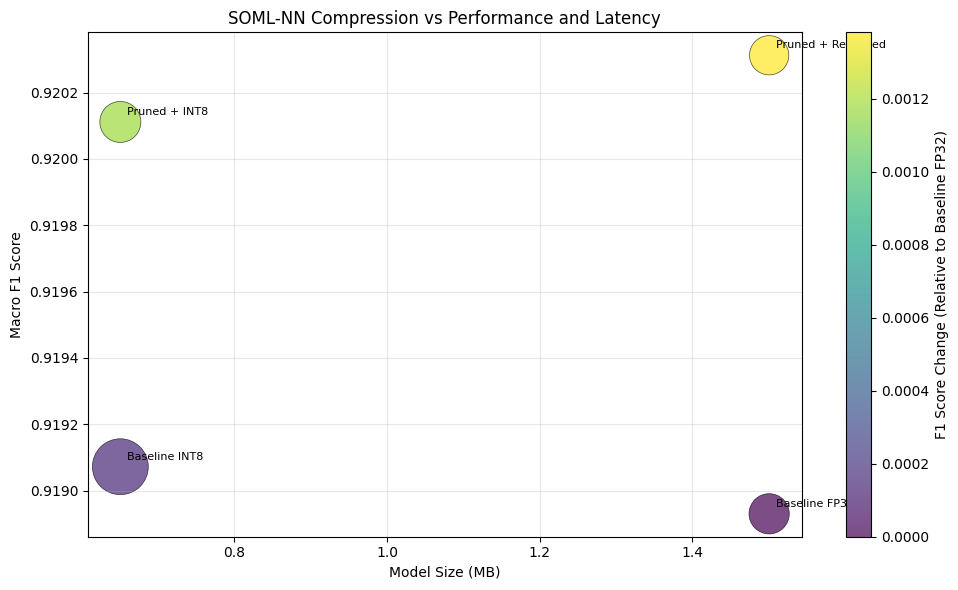

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_results["Size_MB"],
    df_results["F1"],
    s=df_results["Latency_ms"] * 600,
    c=df_results["F1_Change"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

for _, row in df_results.iterrows():
    plt.annotate(
        row["Model"],
        (row["Size_MB"], row["F1"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

plt.xlabel("Model Size (MB)")
plt.ylabel("Macro F1 Score")
plt.title("SOML-NN Compression vs Performance and Latency")

plt.grid(True, alpha=0.3)


cbar = plt.colorbar(scatter)
cbar.set_label("F1 Score Change (Relative to Baseline FP32)")

plt.tight_layout()
plt.show()